In [6]:
import healpy as hp 
import numpy as np 
import pylab as pl 

In [108]:
print(np.load( fname ) ['g4']) 

[1.31798048]


3072 3072


/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_88750/3339028580.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


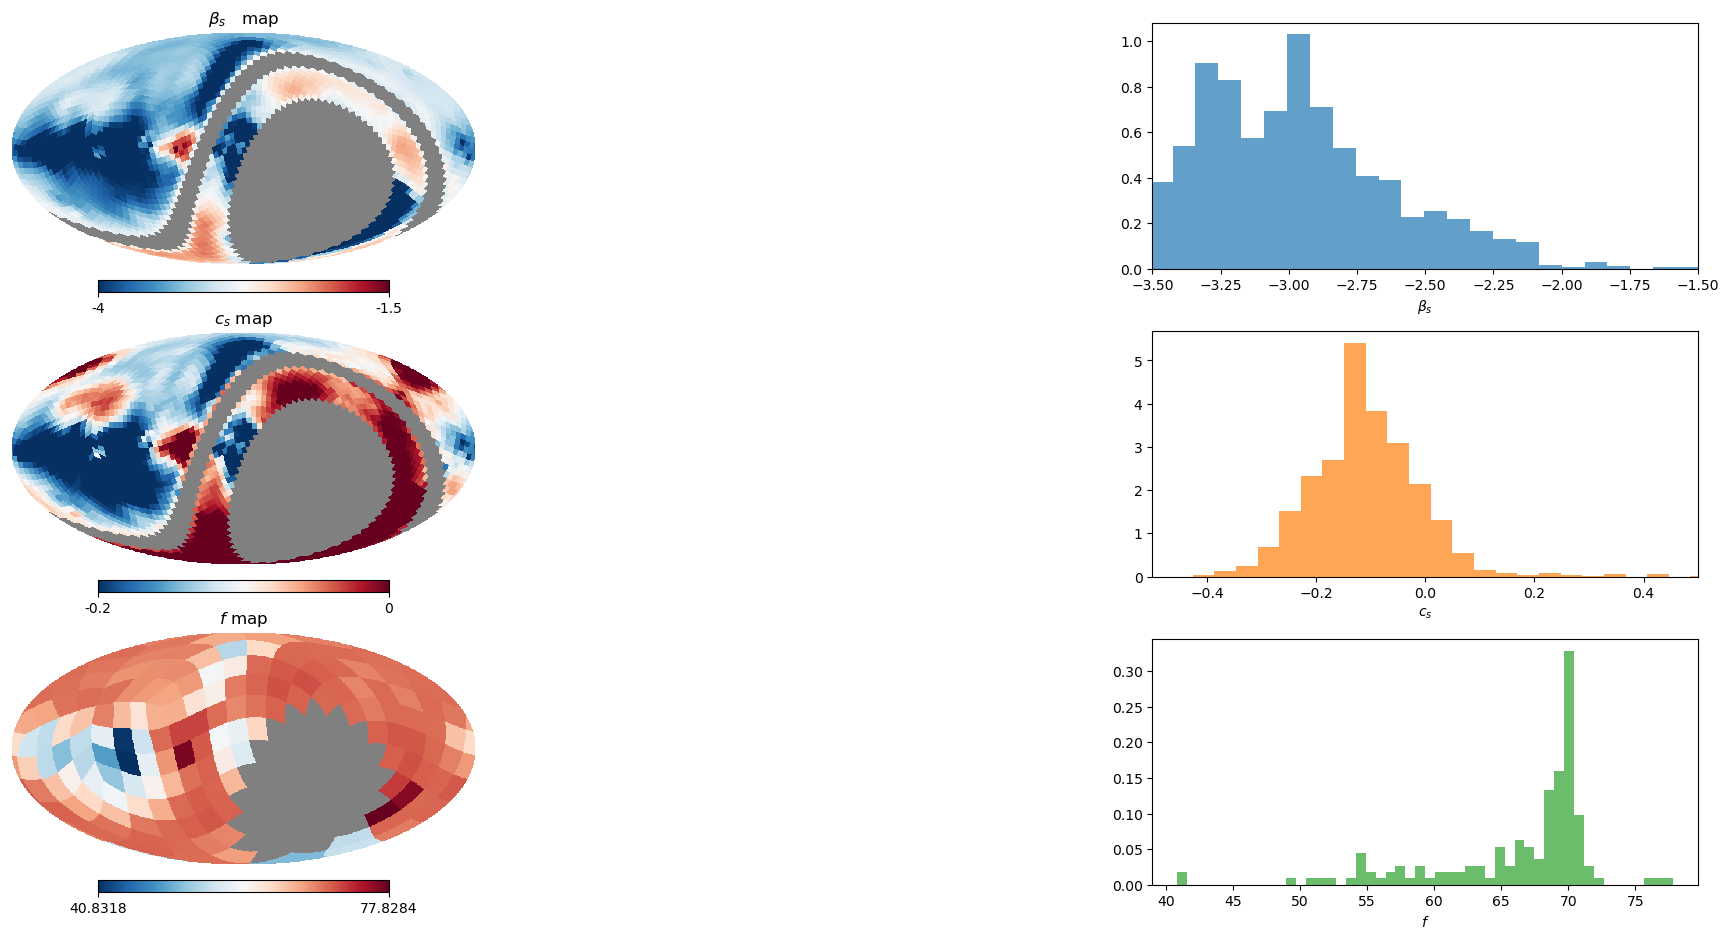

In [112]:
fname ='../outputs/fgbuster_params_north_depth_nside16.npz' 
betamap = np.load( fname )['Synchrotron.beta_pl' ] 
csmap = np.load( fname ) ['Synchrotron.running'] 
pivot=   np.load( fname ) [ 'Synchrotron.nu_pivot'] 
print(betamap.size , csmap.size )
fig, axes = pl.subplots(4, 3, figsize=(18, 12))
mask_uns= np.ma.masked_equal(betamap , hp.UNSEEN ) .mask 
betamap[mask_uns]   =np.nan
csmap[mask_uns]   =np.nan
mask_uns= np.ma.masked_equal(pivot , hp.UNSEEN ) .mask 
pivot[mask_uns]   =np.nan
# 1st row: betamap
hp.mollview(betamap, sub=(4, 3, 1), min=-4., max=-1.5,  cmap='RdBu_r', coord='CG', notext=True,  title=r'$\beta_s$   map' )
axes[0, 2].hist(betamap[~np.isnan(betamap)], bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$')
#axes[0, 2].set_ylabel('Density')
axes[0, 2].set_xlim( [-3.5, -1.5])


# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.2, max=0.,  cmap='RdBu_r', coord='CG', notext=True, fig=fig, title=r'$c_s$ map')


axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C1', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$')
axes[1, 2].set_xlim( [-.5, .5 ])

#axes[1, 2].set_ylabel('Density')

# 3rd row: fmap
hp.mollview(pivot, sub=(4, 3, 7),  cmap='RdBu_r' , coord='CG', notext=True, fig=fig, title=r'$f$ map')

axes[2, 2].hist(pivot[~np.isnan(pivot )], bins=50, density=True, color='C2', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$')

 
# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()

12288 12288


/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_88750/466052626.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


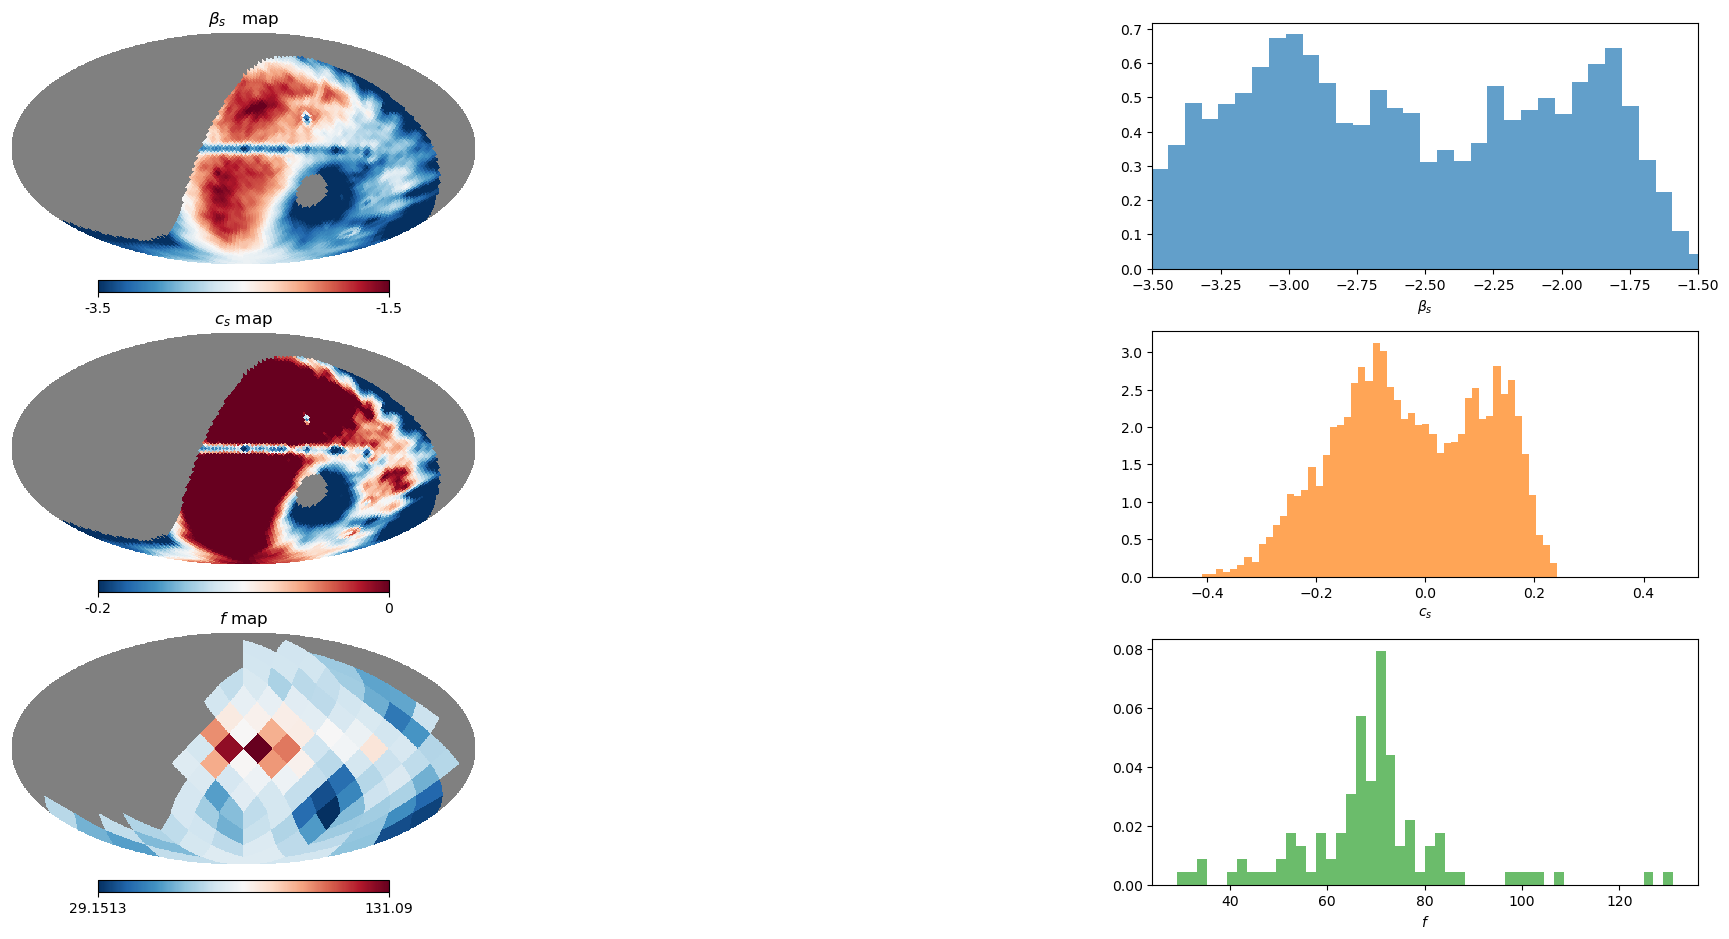

In [102]:
fname ='../fgbuster_params_south_nside32.npz' 
betamap = np.load( fname )['Synchrotron.beta_pl' ] 
csmap = np.load( fname ) ['Synchrotron.running'] 
pivot=   np.load( fname ) [ 'Synchrotron.nu_pivot'] 
print(betamap.size , csmap.size )
fig, axes = pl.subplots(4, 3, figsize=(18, 12))
mask_uns= np.ma.masked_equal(betamap , hp.UNSEEN ) .mask 
betamap[mask_uns]   =np.nan
csmap[mask_uns]   =np.nan
mask_uns= np.ma.masked_equal(pivot , hp.UNSEEN ) .mask 
pivot[mask_uns]   =np.nan
# 1st row: betamap
hp.mollview(betamap, sub=(4, 3, 1), min=-3.5, max=-1.5,  cmap='RdBu_r',  notext=True,  title=r'$\beta_s$   map' )
axes[0, 2].hist(betamap[~np.isnan(betamap)], bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$')
#axes[0, 2].set_ylabel('Density')
axes[0, 2].set_xlim( [-3.5, -1.5])


# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.2, max=0.,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$c_s$ map')


axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C1', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$')
axes[1, 2].set_xlim( [-.5, .5 ])

#axes[1, 2].set_ylabel('Density')

# 3rd row: fmap
hp.mollview(pivot, sub=(4, 3, 7),  cmap='RdBu_r' ,  notext=True, fig=fig, title=r'$f$ map')

axes[2, 2].hist(pivot[~np.isnan(pivot )], bins=50, density=True, color='C2', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$')

 
# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()


def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out

listpix = hp.query_strip(nside=hp.get_nside(apo_cel), theta1=np.pi/2, theta2=np.pi  )
 
north= hp.read_map('../outputs/bfit_maps_hp.fits', field=None )[0]
nans = np.ma.masked_invalid(north).mask 
apo_cel = hp.read_map('../outputs/common_footprint_apo.fits', field=0 )
north [nans] = 0.0
north[listpix]=0 
north*=apo_cel
north = rotate_map(north, 'C', 'G')
south= hp.read_map('../outputs/bfit_maps_south_11.fits', field=None )[0]

nans = np.ma.masked_invalid(south).mask 
south[nans] = 0.0

hp.mollview(north, sub=(2, 1, 1),   title='North')
hp.mollview(south, coord='GC')
hp.graticule() 

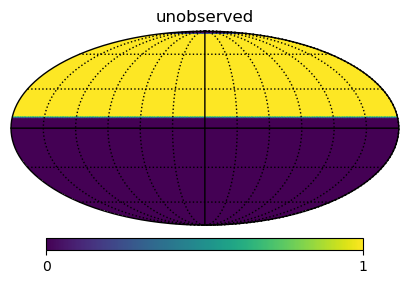

In [ ]:

hp.mollview( apo_cel , sub=(2, 1, 2), title='unobserved'); hp.graticule() 


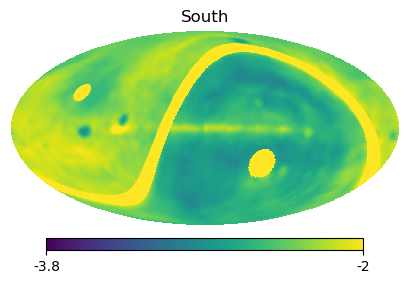

In [69]:
hp.mollview(( south )+north ,min=-3.8,max=-2 , sub=(2, 1, 2), title='South')


In [88]:

masknorth =hp.read_map('../outputs/common_footprint_coarse.fits') 
masksouth =hp.read_map('../outputs/common_footprint_southern.fits') 
mymn= np.zeros_like (masknorth)
myms= np.zeros_like (masknorth)
listn = hp.query_strip(nside=hp.get_nside(mymn ), theta1=np.radians(5) , theta2=np.radians(84 )  )
lists = hp.query_strip(nside=hp.get_nside(mymn ), theta1=np.pi/2, theta2=np.radians(170 )  )
mymn[listn]=1
myms[lists]=1 
print(listn )

[  1512   1513   1514 ... 351741 351742 351743]


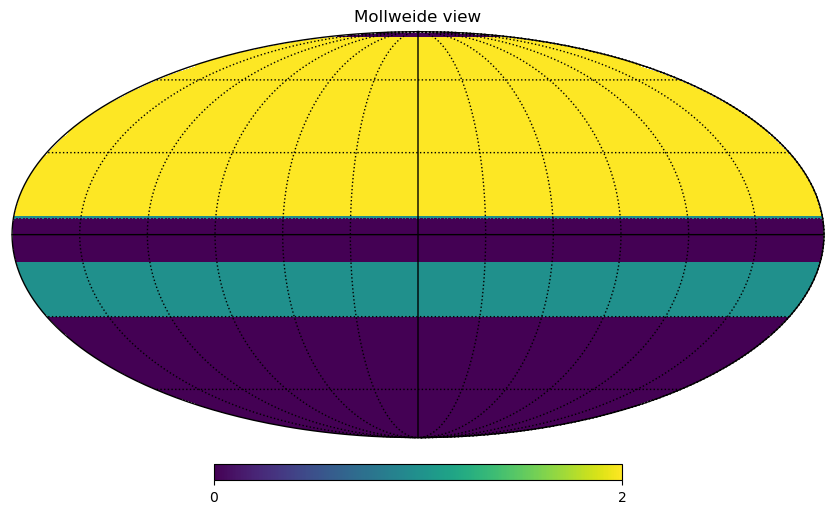

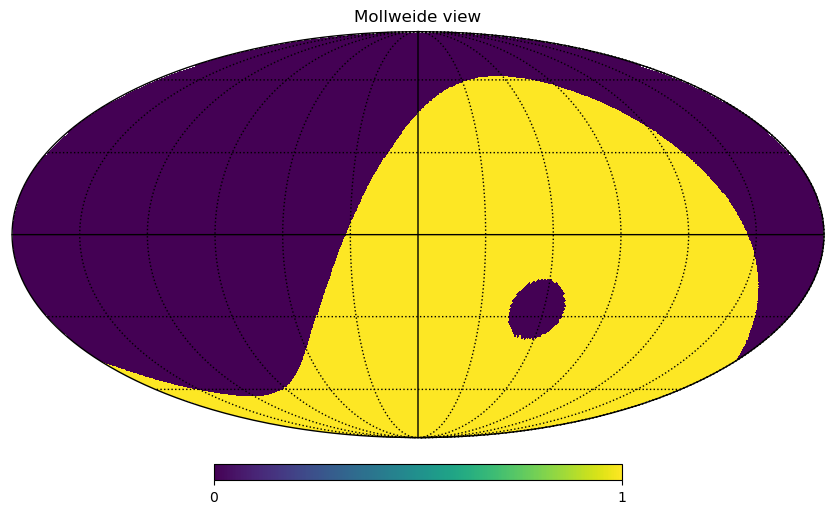

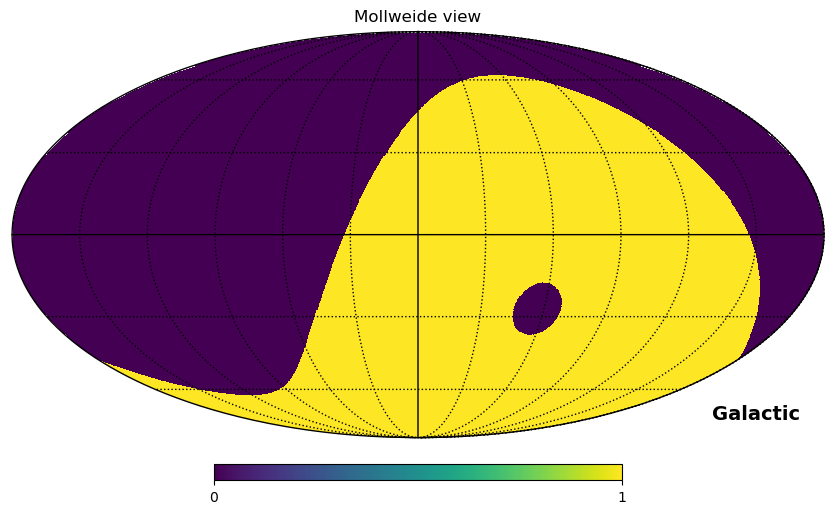

In [95]:
hp.mollview( mymn +masknorth  ); hp.graticule   ()
hp.mollview(masksouth   );hp.graticule   ()
hp.mollview(myms, coord='CG');hp.graticule   ()
